In [130]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [131]:
airports_df = pd.read_csv('./Dataset/Airports Data.csv')
flight_df = pd.read_csv('./Dataset/Flight Level Data.csv')
pnr_flight_df = pd.read_csv('./Dataset/PNR+Flight+Level+Data.csv')
pnr_remark_df = pd.read_csv('./Dataset/PNR Remark Level Data.csv')
bag_df = pd.read_csv('./Dataset/Bag+Level+Data.csv')

Shape of Dataset

In [132]:
print("Flight Data:", flight_df.shape)
print("PNR Flight Data:", pnr_flight_df.shape)
print("PNR Remark Data:", pnr_remark_df.shape)
print("Bag Data:", bag_df.shape)
print("Airport Data:", airports_df.shape)

Flight Data: (8099, 15)
PNR Flight Data: (687878, 12)
PNR Remark Data: (51698, 4)
Bag Data: (687245, 8)
Airport Data: (5612, 2)


What is the average delay and what percentage of flights depart later than scheduled?

Convert datetime

In [133]:
flight_df['actual_departure_datetime_local'] = pd.to_datetime(flight_df['actual_departure_datetime_local'], errors='coerce')
flight_df['scheduled_departure_datetime_local'] = pd.to_datetime(flight_df['scheduled_departure_datetime_local'], errors='coerce')

Delay Calculations

In [134]:
flight_df['delay_minutes'] = (flight_df['actual_departure_datetime_local'] - flight_df['scheduled_departure_datetime_local']).dt.total_seconds() / 60
avg_delay = flight_df['delay_minutes'].mean()
pct_late = (flight_df['delay_minutes'] > 0).mean() * 100
print(f'Average delay: {avg_delay:.2f} minutes')
print(f'Percentage of flights departing late: {pct_late:.2f}%')

Average delay: 21.18 minutes
Percentage of flights departing late: 49.61%


Plots of Delay

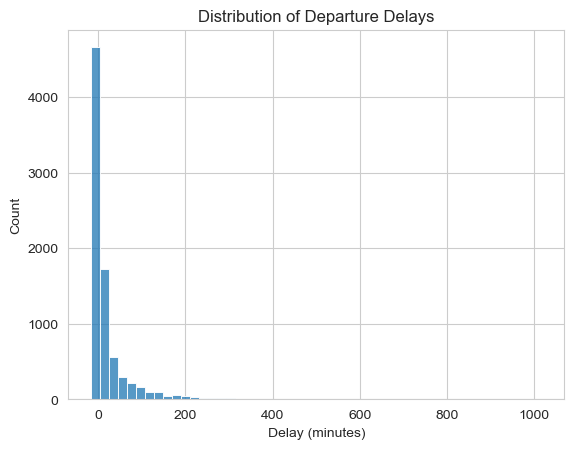

In [135]:
sns.histplot(flight_df['delay_minutes'], bins=50)
plt.title('Distribution of Departure Delays')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.savefig('./Output_Images/delay_distribution.png')
plt.show()

How many flights have scheduled ground time close to or below the minimum turn mins?

Calculation

In [136]:
flight_df['ground_time_ratio'] = flight_df['scheduled_ground_time_minutes'] / flight_df['minimum_turn_minutes']
flight_df['is_tight_ground'] = (flight_df['scheduled_ground_time_minutes'] <= flight_df['minimum_turn_minutes'] * 1.1).astype(int)
tight_ground_pct = flight_df['is_tight_ground'].mean() * 100
tight_ground_count = flight_df['is_tight_ground']
# Count how many flights are tight
tight_ground_count = flight_df['is_tight_ground'].sum()

# Total flights
total_flights = len(flight_df)

# Print results
print(f"Total flights analyzed: {total_flights}")
print(f"Tight ground flights: {tight_ground_count}")

Total flights analyzed: 8099
Tight ground flights: 780


Percentage of flights with tight ground time: 9.63%
Flights that have scheduled ground time close to or below the minimum turn mins: 780


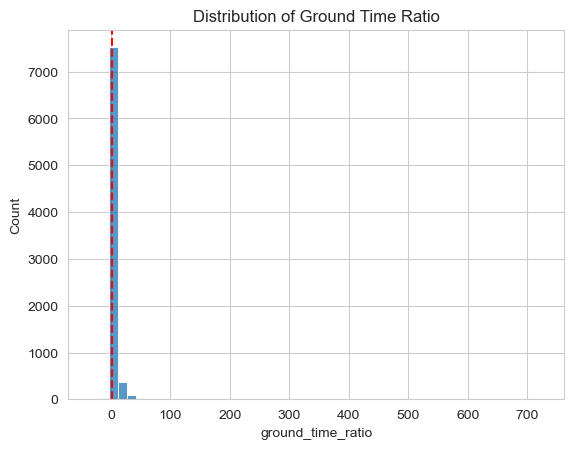

In [137]:
print(f'Percentage of flights with tight ground time: {tight_ground_pct:.2f}%')
print(f'Flights that have scheduled ground time close to or below the minimum turn mins: {tight_ground_count}')
sns.histplot(flight_df['ground_time_ratio'], bins=50)
plt.axvline(1.1, color='red', linestyle='--', label='Tight Ground Threshold')
plt.title('Distribution of Ground Time Ratio')
plt.savefig('ground_time_ratio.png')

The average ratio of transfer bags vs. checked bags across flights

Create route identifier

Dropping flight_number

In [138]:
# --- 2. Calculate Passenger Load ---
# Group the PNR data by each unique flight to count the total number of passengers.
# We are using .drop_duplicates() because each passenger in a multi-person booking (e.g., total_pax=4) might have their own row.
# We only want to count the 'total_pax' value once per unique booking (record_locator).
pax_per_booking = pnr_flight_df[['company_id', 'flight_number', 'scheduled_departure_date_local', 'record_locator', 'total_pax']].drop_duplicates()
passenger_counts = pax_per_booking.groupby(['company_id', 'flight_number', 'scheduled_departure_date_local'])['total_pax'].sum().reset_index()
passenger_counts.rename(columns={'total_pax': 'total_passengers'}, inplace=True)

In [139]:
# --- 3. Consolidate Data and Calculate Load Factor ---
# Merge the passenger counts into the main flight data table.
flight_data_with_passengers = pd.merge(
    flight_df,
    passenger_counts,
    on=['company_id', 'flight_number', 'scheduled_departure_date_local'],
    how='left' # Use a left merge to keep all flights, even if they have no passenger data
)

In [140]:
# Calculate the load factor for each flight.
flight_data_with_passengers['load_factor'] = (flight_data_with_passengers['total_passengers'] / flight_data_with_passengers['total_seats']) * 100
# Fill any potential missing passenger data with 0
flight_data_with_passengers['load_factor'].fillna(0, inplace=True)

In [141]:
# --- 4. Calculate Operational Difficulty Metrics ---
# Convert the scheduled and actual times to datetime objects to perform calculations.
for col in ['scheduled_departure_datetime_local', 'actual_departure_datetime_local', 'scheduled_arrival_datetime_local', 'actual_arrival_datetime_local']:
    flight_data_with_passengers[col] = pd.to_datetime(flight_data_with_passengers[col])

In [142]:
# Calculate departure and arrival delays in minutes.
flight_data_with_passengers['departure_delay'] = (flight_data_with_passengers['actual_departure_datetime_local'] - flight_data_with_passengers['scheduled_departure_datetime_local']).dt.total_seconds() / 60
flight_data_with_passengers['arrival_delay'] = (flight_data_with_passengers['actual_arrival_datetime_local'] - flight_data_with_passengers['scheduled_arrival_datetime_local']).dt.total_seconds() / 60

# Determine if the turnaround time was challenging.
flight_data_with_passengers['turnaround_difficulty'] = flight_data_with_passengers['actual_ground_time_minutes'] < flight_data_with_passengers['minimum_turn_minutes']

In [143]:
# --- 5. Analyze and Visualize the Results ---

# Print the correlation matrix to see the statistical relationship
print("\n--- Correlation Matrix ---")
# We only select the columns of interest for the correlation matrix
correlation_matrix = flight_data_with_passengers[['load_factor', 'departure_delay', 'arrival_delay', 'turnaround_difficulty']].corr()
print(correlation_matrix)
print("\nGenerating plots...")

# Set a style for the plots
sns.set_style("whitegrid")




--- Correlation Matrix ---
                       load_factor  departure_delay  arrival_delay  \
load_factor               1.000000        -0.176292      -0.171493   
departure_delay          -0.176292         1.000000       0.928553   
arrival_delay            -0.171493         0.928553       1.000000   
turnaround_difficulty    -0.105982         0.081722       0.076182   

                       turnaround_difficulty  
load_factor                        -0.105982  
departure_delay                     0.081722  
arrival_delay                       0.076182  
turnaround_difficulty               1.000000  

Generating plots...


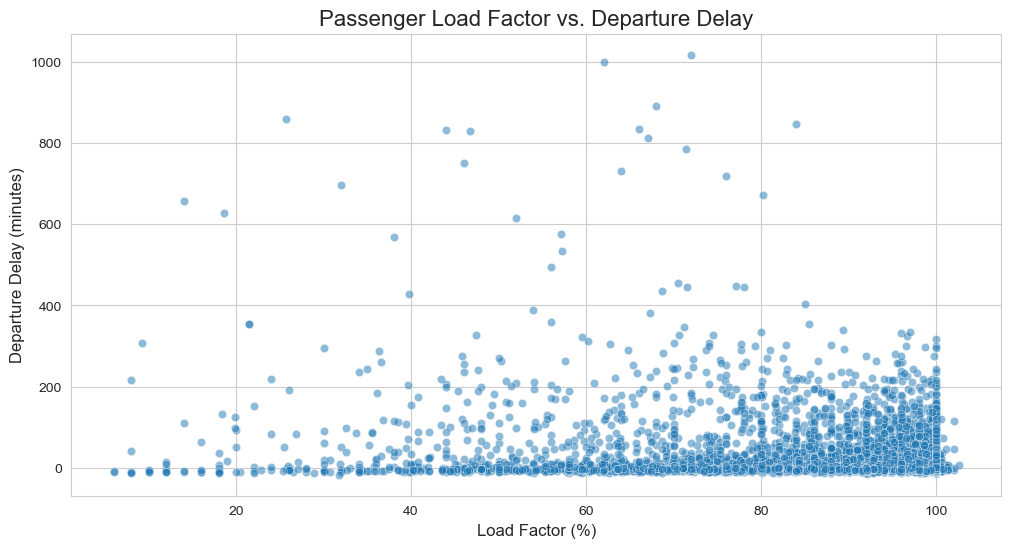

In [144]:
# a) Scatter Plot: Load Factor vs. Departure Delay
plt.figure(figsize=(12, 6))
sns.scatterplot(data=flight_data_with_passengers, x='load_factor', y='departure_delay', alpha=0.5)
plt.title('Passenger Load Factor vs. Departure Delay', fontsize=16)
plt.xlabel('Load Factor (%)', fontsize=12)
plt.ylabel('Departure Delay (minutes)', fontsize=12)
plt.savefig('load_factor_vs_departure_delay.png')
plt.show()

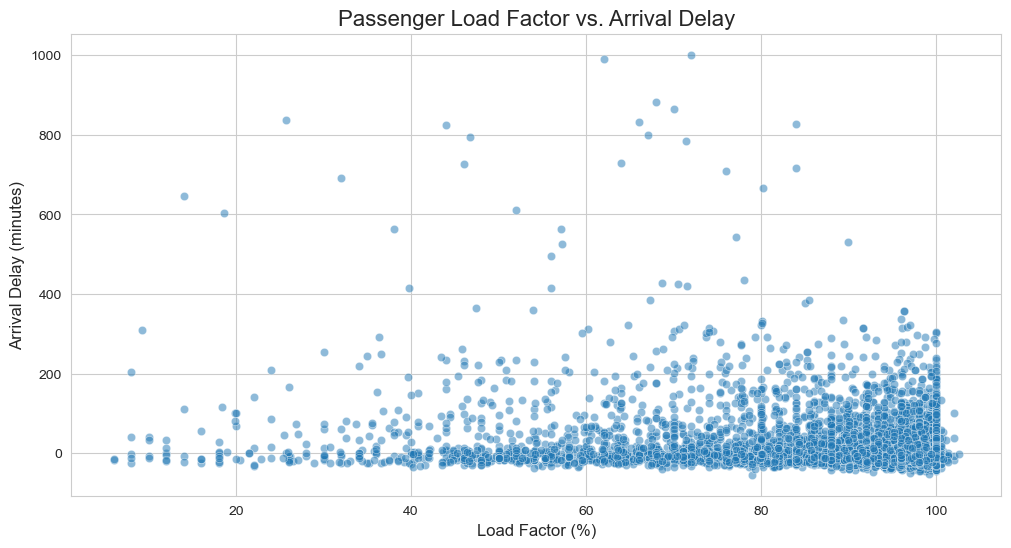

In [145]:
# b) Scatter Plot: Load Factor vs. Arrival Delay
plt.figure(figsize=(12, 6))
sns.scatterplot(data=flight_data_with_passengers, x='load_factor', y='arrival_delay', alpha=0.5)
plt.title('Passenger Load Factor vs. Arrival Delay', fontsize=16)
plt.xlabel('Load Factor (%)', fontsize=12)
plt.ylabel('Arrival Delay (minutes)', fontsize=12)
plt.savefig('load_factor_vs_arrival_delay.png')
plt.show()

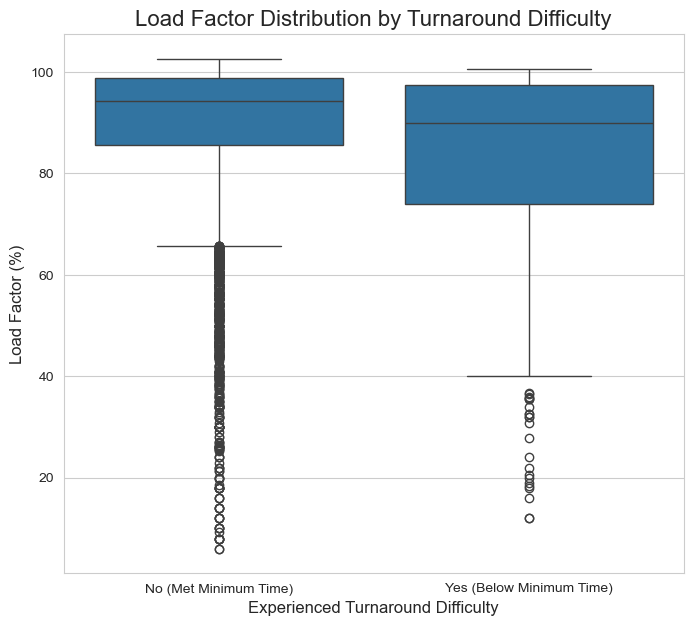


Analysis complete. Plots have been generated and saved as PNG files.


In [146]:
# c) Box Plot: Load Factor by Turnaround Difficulty
plt.figure(figsize=(8, 7))
sns.boxplot(data=flight_data_with_passengers, x='turnaround_difficulty', y='load_factor')
plt.title('Load Factor Distribution by Turnaround Difficulty', fontsize=16)
plt.xlabel('Experienced Turnaround Difficulty', fontsize=12)
plt.ylabel('Load Factor (%)', fontsize=12)
plt.xticks(ticks=[False, True], labels=['No (Met Minimum Time)', 'Yes (Below Minimum Time)'])
plt.savefig('load_factor_vs_turnaround_difficulty.png')
plt.show()

print("\nAnalysis complete. Plots have been generated and saved as PNG files.")

In [147]:
# Aggregate PNR-level passengers to flight-level
pax_summary = (
    pnr_flight_df
    .groupby(['flight_number','scheduled_departure_date_local',
              'scheduled_departure_station_code','scheduled_arrival_station_code'], as_index=False)
    .agg(total_pax=('total_pax','sum'))
)

In [148]:
flight_with_pax = flight_df.merge(
    pax_summary,
    on=['flight_number','scheduled_departure_date_local',
        'scheduled_departure_station_code','scheduled_arrival_station_code'],
    how='left'
)

In [149]:
flight_with_pax['load_factor'] = flight_with_pax['total_pax'] / flight_with_pax['total_seats']

In [150]:
flight_with_pax['delay_min'] = (
    pd.to_datetime(flight_with_pax['actual_departure_datetime_local']) -
    pd.to_datetime(flight_with_pax['scheduled_departure_datetime_local'])
).dt.total_seconds() / 60

flight_with_pax['late_flag'] = flight_with_pax['delay_min'] > 15

In [151]:
# Correlation
corr = flight_with_pax[['load_factor','delay_min']].corr(method='spearman')

# Example logistic regression
import statsmodels.api as sm
X = sm.add_constant(flight_with_pax[['load_factor']])
y = flight_with_pax['late_flag'].astype(int)
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.578899
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              late_flag   No. Observations:                 8099
Model:                          Logit   Df Residuals:                     8097
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Oct 2025   Pseudo R-squ.:                0.002453
Time:                        00:30:19   Log-Likelihood:                -4688.5
converged:                       True   LL-Null:                       -4700.0
Covariance Type:            nonrobust   LLR p-value:                 1.572e-06
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4320      0.122     -3.552      0.000      -0.670      -0.194
load_factor    -0.5670      0.117     -4.826      0.000      -0.797      -0.337
===============================================================================
"""

In [152]:
flight_with_pax.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,...,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes,delay_minutes,ground_time_ratio,is_tight_ground,total_pax,load_factor,delay_min,late_flag
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04T21:04:00Z,2025-08-04 18:04:00+00:00,2025-08-04T20:52:00Z,76,...,42,34,34,7.0,1.235294,0,65,0.855263,7.0,False
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04T08:20:00Z,2025-08-03 18:27:00+00:00,2025-08-04T08:06:00Z,167,...,235,229,145,22.0,1.620690,0,171,1.023952,22.0,True
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10T21:35:00Z,2025-08-10 20:11:00+00:00,2025-08-10T23:26:00Z,166,...,76,69,51,111.0,1.490196,0,180,1.084337,111.0,True
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06T21:04:00Z,2025-08-06 20:05:00+00:00,2025-08-06T22:42:00Z,50,...,223,38,29,105.0,7.689655,0,55,1.100000,105.0,True
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05T21:29:00Z,2025-08-05 18:16:00+00:00,2025-08-05T21:49:00Z,166,...,75,72,51,-4.0,1.470588,0,136,0.819277,-4.0,False


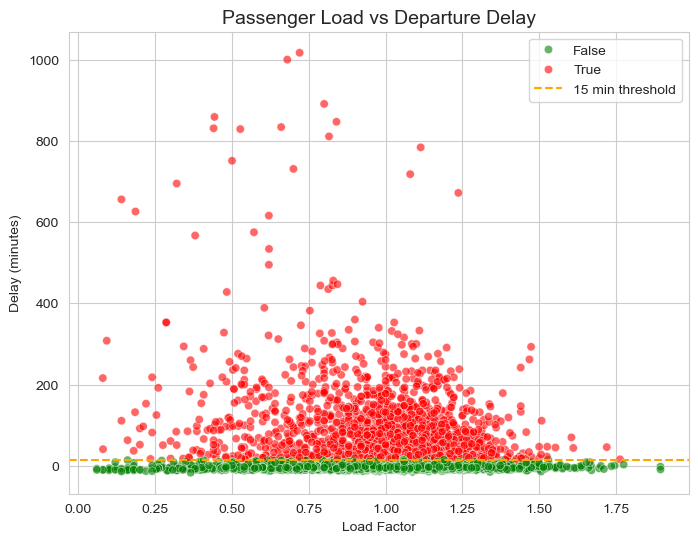

In [153]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=flight_with_pax,
    x='load_factor',
    y='delay_min',
    hue='late_flag',
    palette={True:"red", False:"green"},
    alpha=0.6
)
plt.axhline(15, color='orange', linestyle='--', label="15 min threshold")
plt.title("Passenger Load vs Departure Delay", fontsize=14)
plt.xlabel("Load Factor")
plt.ylabel("Delay (minutes)")
plt.legend()
plt.show()

C:\Users\SOURAV\AppData\Local\Temp\ipykernel_20536\444744844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flight_with_pax, x='load_group', y='delay_min', palette="Set2")


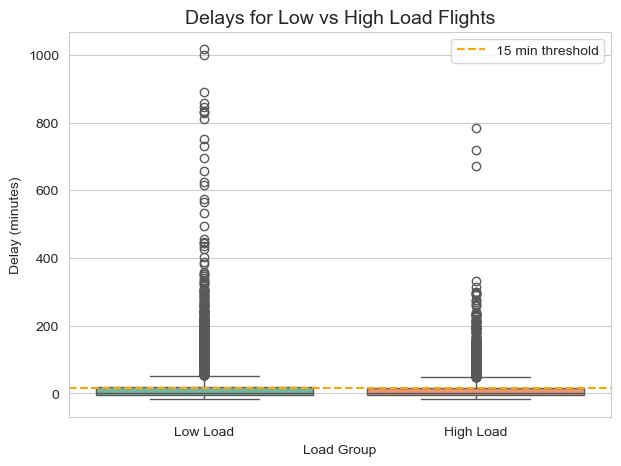

In [154]:
median_load = flight_with_pax['load_factor'].median()
flight_with_pax['load_group'] = np.where(flight_with_pax['load_factor'] >= median_load, "High Load", "Low Load")

plt.figure(figsize=(7,5))
sns.boxplot(data=flight_with_pax, x='load_group', y='delay_min', palette="Set2")
plt.axhline(15, color='orange', linestyle='--', label="15 min threshold")
plt.title("Delays for Low vs High Load Flights", fontsize=14)
plt.xlabel("Load Group")
plt.ylabel("Delay (minutes)")
plt.legend()
plt.show()

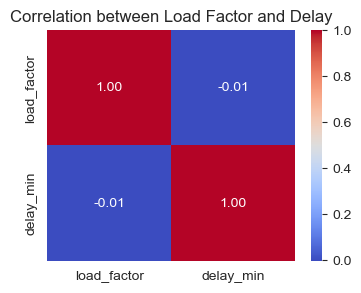

In [155]:
plt.figure(figsize=(4,3))
sns.heatmap(flight_with_pax[['load_factor','delay_min']].corr(method='spearman'),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Load Factor and Delay")
plt.show()

SSR and load factor


In [156]:
# 2a. Aggregate total passengers per flight
pax_summary = (
    pnr_flight_df
    .groupby(['flight_number','scheduled_departure_date_local',
              'scheduled_departure_station_code','scheduled_arrival_station_code'], as_index=False)
    .agg(total_pax=('total_pax','sum'))
)

In [158]:
# 2b. Merge SSRs with flight identifiers from pnr_flight_df
pnr_remark_df = pnr_remark_df.merge(
    pnr_flight_df[[
        'record_locator', 'flight_number', 'scheduled_departure_date_local',
        'scheduled_departure_station_code', 'scheduled_arrival_station_code'
    ]].drop_duplicates(),
    on=['record_locator','flight_number'],
    how='left'
)

In [160]:
# 2c. Aggregate SSR count per flight
ssr_summary = (
    pnr_remark_df
    .groupby(['flight_number','scheduled_departure_date_local',
              'scheduled_departure_station_code','scheduled_arrival_station_code'], as_index=False)
    .agg(special_requests_count=('special_service_request','count'))
)


In [161]:
# 2d. Merge passenger load and SSR count into flight_df
flight_with_pax = flight_df.merge(
    pax_summary,
    on=['flight_number','scheduled_departure_date_local',
        'scheduled_departure_station_code','scheduled_arrival_station_code'],
    how='left'
)

flight_with_pax = flight_with_pax.merge(
    ssr_summary,
    on=['flight_number','scheduled_departure_date_local',
        'scheduled_departure_station_code','scheduled_arrival_station_code'],
    how='left'
)

In [162]:
# Fill missing values
flight_with_pax['total_pax'] = flight_with_pax['total_pax'].fillna(0)
flight_with_pax['special_requests_count'] = flight_with_pax['special_requests_count'].fillna(0)

In [163]:
# ================================================
# 3️⃣ Compute load factor and delay metrics
# ================================================
flight_with_pax['load_factor'] = flight_with_pax['total_pax'] / flight_with_pax['total_seats']

flight_with_pax['delay_min'] = (
    pd.to_datetime(flight_with_pax['actual_departure_datetime_local']) -
    pd.to_datetime(flight_with_pax['scheduled_departure_datetime_local'])
).dt.total_seconds() / 60

flight_with_pax['late_flag'] = (flight_with_pax['delay_min'] > 15).astype(int)

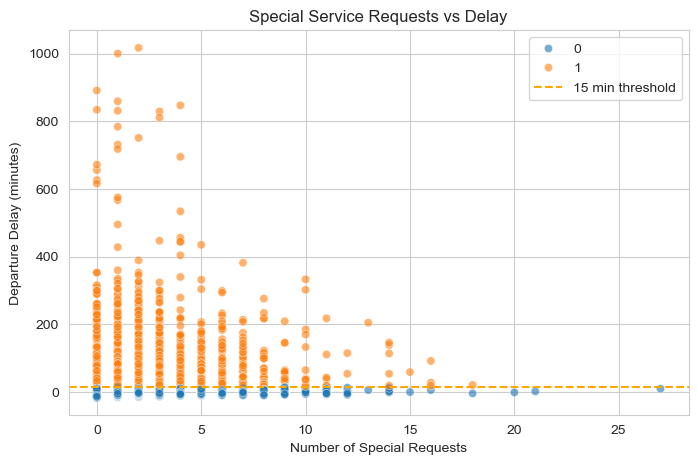

In [164]:
# ================================================
# 4️⃣ Exploratory plots
# ================================================
# Load vs Delay scatter
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=flight_with_pax,
    x='special_requests_count',
    y='delay_min',
    hue='late_flag',
    alpha=0.6
)
plt.axhline(15, color='orange', linestyle='--', label='15 min threshold')
plt.title("Special Service Requests vs Delay")
plt.xlabel("Number of Special Requests")
plt.ylabel("Departure Delay (minutes)")
plt.legend()
plt.show()


C:\Users\SOURAV\AppData\Local\Temp\ipykernel_20536\4055986787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flight_with_pax, x='ssr_group', y='delay_min', palette="Set2")


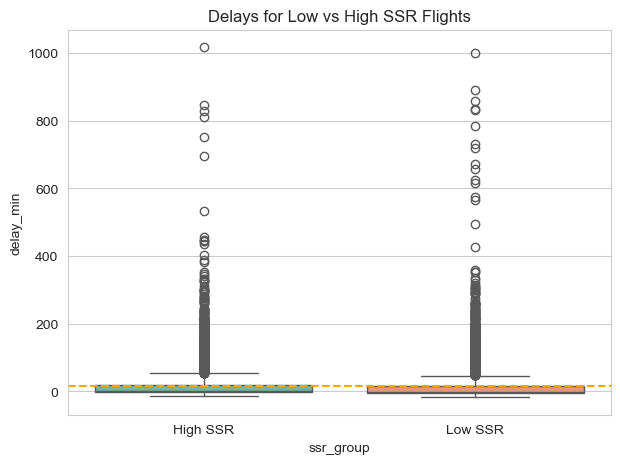

In [166]:
# Boxplot: High vs Low SSR flights
median_ssr = flight_with_pax['special_requests_count'].median()
flight_with_pax['ssr_group'] = np.where(flight_with_pax['special_requests_count'] >= median_ssr, "High SSR", "Low SSR")

plt.figure(figsize=(7,5))
sns.boxplot(data=flight_with_pax, x='ssr_group', y='delay_min', palette="Set2")
plt.axhline(15, color='orange', linestyle='--')
plt.title("Delays for Low vs High SSR Flights")
plt.show()

In [167]:
# ================================================
# 5️⃣ Regression Analysis (controlling for passenger load)
# ================================================
# Linear regression (delay minutes)
X = flight_with_pax[['total_pax','special_requests_count']]
X = sm.add_constant(X)
y = flight_with_pax['delay_min']

ols_model = sm.OLS(y, X).fit()
print("=== Linear Regression: Delay vs Pax + SSR ===")
print(ols_model.summary())

# Logistic regression (late_flag)
y_bin = flight_with_pax['late_flag']
logit_model = sm.Logit(y_bin, X).fit()
print("=== Logistic Regression: Late Flag vs Pax + SSR ===")
print(logit_model.summary())

=== Linear Regression: Delay vs Pax + SSR ===
                            OLS Regression Results                            
Dep. Variable:              delay_min   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     11.41
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           1.13e-05
Time:                        00:32:57   Log-Likelihood:                -44928.
No. Observations:                8099   AIC:                         8.986e+04
Df Residuals:                    8096   BIC:                         8.988e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------